In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import seaborn as sns
import librosa

## Ejercicio 1

Implemente una función para el cálculo y graficación del espectrograma a partir de ciclos for y la transformada rápida de Fourier.

In [147]:
def generar_senoidal(N, frecs, frecM, std=None):
    # N = n° segundos
    Tm = 1/frecM

    dom = np.arange(0, N, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        if std is not None:
            senoidal *= np.random.rand() * std

        senoidal_final += senoidal
    
    
    return dom, senoidal_final

def ventanear(tramo, ventana):
    N = len(tramo)
    tramo_ventaneado = tramo.copy()
    match ventana:
        case 'Gabor':
            for i in range(0, N):
                w = np.exp(-9 * i**2)
                tramo_ventaneado[i] *= w

        case 'Blackman':
            for i in range(0, N):
                w = 21/50 - 0.5 * np.cos(2*np.pi*i/(N - 1)) + 2/25 * np.cos(4*np.pi*i/(N - 1))
                tramo_ventaneado[i] *= w

        case 'Hamming':
            for i in range(0, N):
                w = 27/50 - 23/50 * np.cos(2*np.pi*i/(N-1))
                tramo_ventaneado[i] *= w

        case 'Hanning':
            for i in range(0, N):
                w = 0.5 - 0.5 * np.cos(2*np.pi*i/(N-1))
                tramo_ventaneado[i] *= w

        case 'Rectangular':
            # xd
            pass

    return tramo_ventaneado

def espectograma(signal, ventana, Nwin, Nlap, Nfft, start=0):
    cant_tramos = (len(signal) - Nwin)//Nlap + 1
    
    tramos = []
    tramos_fft = []
    for j in range(cant_tramos):
        tramo = signal[start + Nlap * j : start + Nlap * j + Nwin]
        if len(tramo) == Nwin:
            tramo = ventanear(tramo, ventana)
            tramos.append(tramo)

            tramo_fft = np.fft.rfft(tramo, Nfft)
            tramo_densidad = np.pow(np.abs(tramo_fft), 2)
            tramos_fft.append(tramo_densidad)

    tramos = np.array(tramos)
    tramos_fft = np.array(tramos_fft) # cant_tramos x Nfft
    return tramos, tramos_fft.T

def graficar_espectograma(densidades, frecM, Nfft, Nwin, Nlap, freqLap=None, figsize=None, congoflag=False):
    freqs = np.fft.rfftfreq(Nfft, d=1/frecM)

    tiempos = np.arange(densidades.shape[1]) * Nlap / frecM

    if figsize is not None:    
        plt.figure(figsize=figsize)
    else:
        plt.figure(figsize=(8,6))
    plt.title("Espectograma de la señal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    if freqLap is not None:
        plt.yticks(
            np.arange(0, freqs[-1] + 1, freqLap)
        )
    img = plt.imshow(
        10 * np.log10(densidades + 1e-12),
        aspect='auto',
        origin='lower',
        extent=[
            tiempos[0],
            tiempos[-1]+ Nwin/frecM,
            freqs[0],
            freqs[-1]
        ],
        cmap='hsv' if congoflag else 'winter'
    )

    plt.colorbar(img, label='PSD [dB]')
    plt.show()

(19, 100) (51, 19)


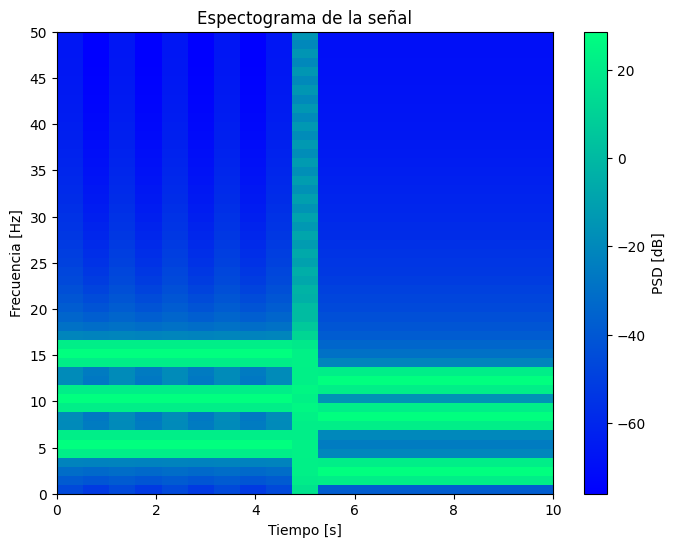

In [148]:
frecM = 100
dom, signal1 = generar_senoidal(10, [5, 10, 15], frecM)
_, signal2 = generar_senoidal(10, [2, 8, 12], frecM)
signal3 = signal1.copy()
signal3[len(signal1)//2:] = signal2[:len(signal1)//2].copy()

a, b = espectograma(signal3, 'Hamming', Nwin=100, Nlap=50, Nfft=100, start=0)
print(a.shape, b.shape)

graficar_espectograma(b, frecM, Nfft=100, Nwin = 100, Nlap=50, freqLap=5)


## Ejercicio 2

Analice una señal de voz mediante el espectrograma, utilizando diferentes solapamientos y anchos de ventana. Discuta los resultados a la luz
del principio de incertidumbre de Heisenberg.

In [149]:
audio, fs = librosa.load("../Unidad-2 PD Voz/PDS_Datos_TP2/audio_aeiou_mas.wav", sr=None)

print(audio.shape)
print(fs)

(36000,)
8000


nwin = 100, nlap = 50


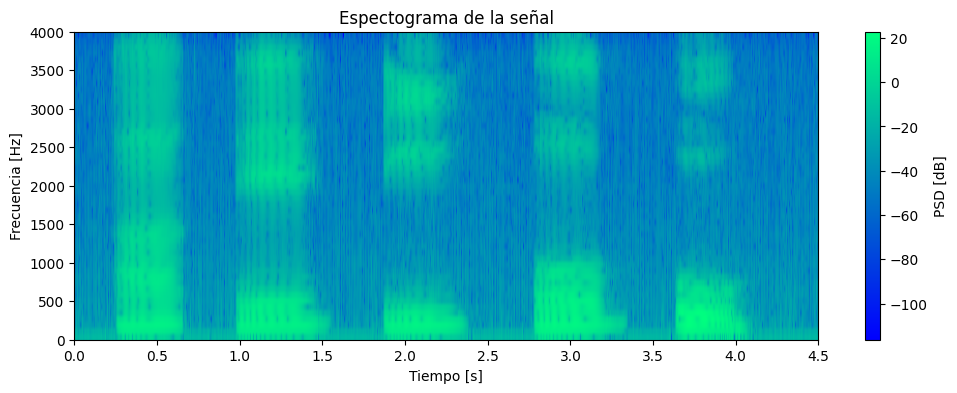

nwin = 100, nlap = 100


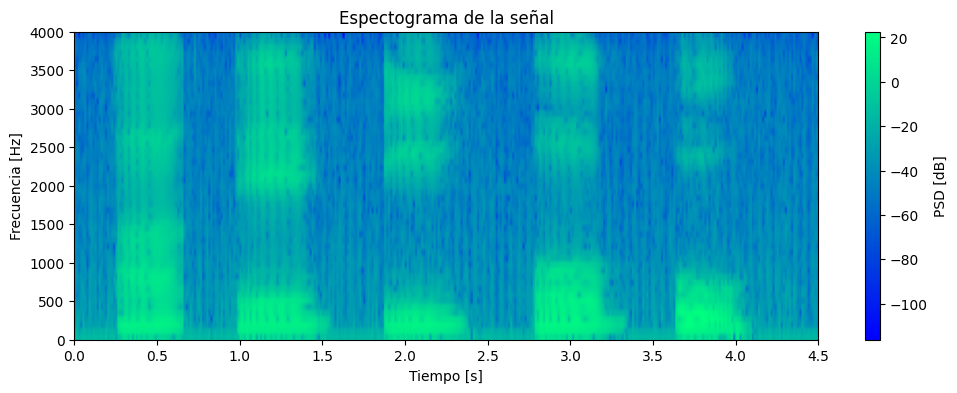

nwin = 5000, nlap = 50


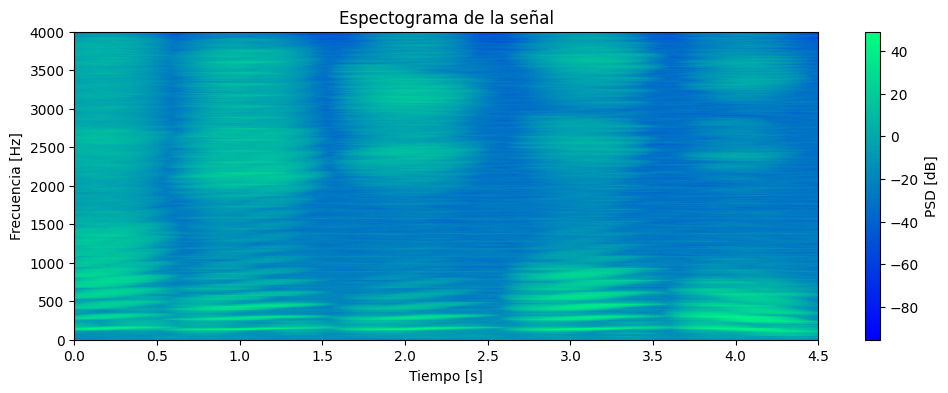

nwin = 5000, nlap = 100


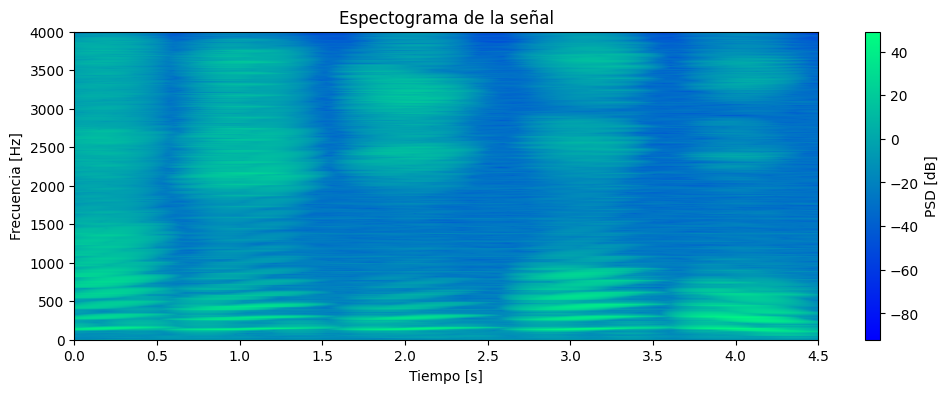

In [150]:
NWIN = [100, 5000]
NLAP = [50, 100]

for i, nwin in enumerate(NWIN):
    for j, nlap in enumerate(NLAP):
        nfft = nwin
        print(f"nwin = {nwin}, nlap = {nlap}")
        a, densidad = espectograma(audio, 'Blackman', Nwin=nwin, Nlap=nlap, Nfft=nfft)
        graficar_espectograma(
            densidad,
            fs,
            Nfft=nfft,
            Nwin=nwin,
            Nlap=nlap,
            freqLap = None,
            figsize=(12,4)
        )


## Ejercicio 3

(401, 100) (201, 401)


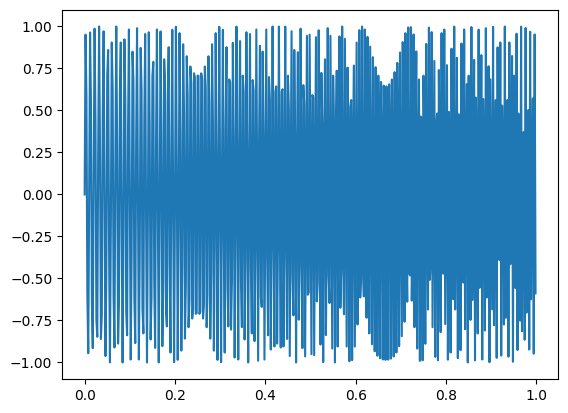

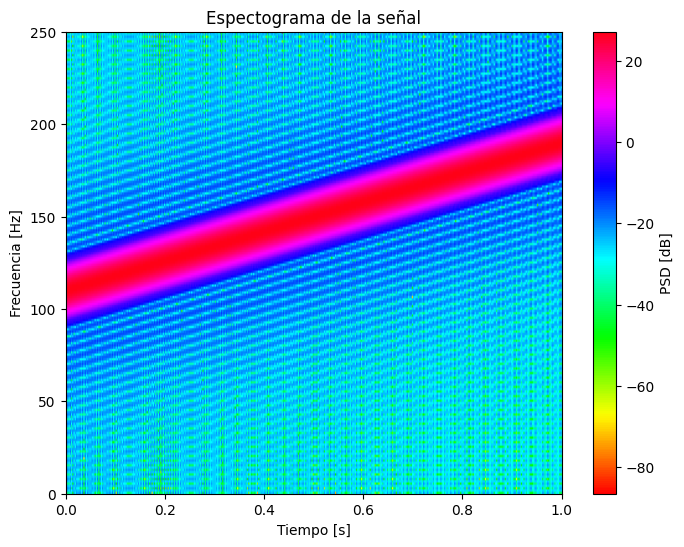

In [155]:
def kernel_lineal(pendiente, frec_min, t):
    return pendiente * t**2 + frec_min * t

def kernel_exp(pendiente, frec_min, t):
    return (frec_min * np.exp(t) - frec_min - t)

def senoidal_mutante(frec_min, frec_max, segundos, frecM, kernel):
    Tm = 1/frecM
    dom = np.arange(0, segundos, Tm)

    pendiente = (frec_max - frec_min)/2
    signal = np.zeros_like(dom)
    for t in range(len(signal)):
        phi_t = 2 * np.pi * kernel(pendiente, frec_min, dom[t])
        signal[t] = np.sin(phi_t)
    
    return dom, signal

dom, signal = senoidal_mutante(100, 200, 1, 500, kernel_lineal)
plt.plot(dom, signal)

a, b = espectograma(signal, 'Hamming', Nwin=100, Nlap=1, Nfft=400, start=0)
print(a.shape, b.shape)

graficar_espectograma(b, 500, Nwin=100, Nlap=1, Nfft=400, freqLap=None, congoflag=True)

## Ejercicio 4

(251, 50) (201, 251)


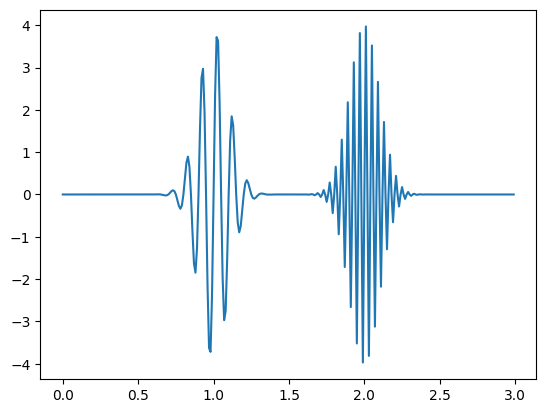

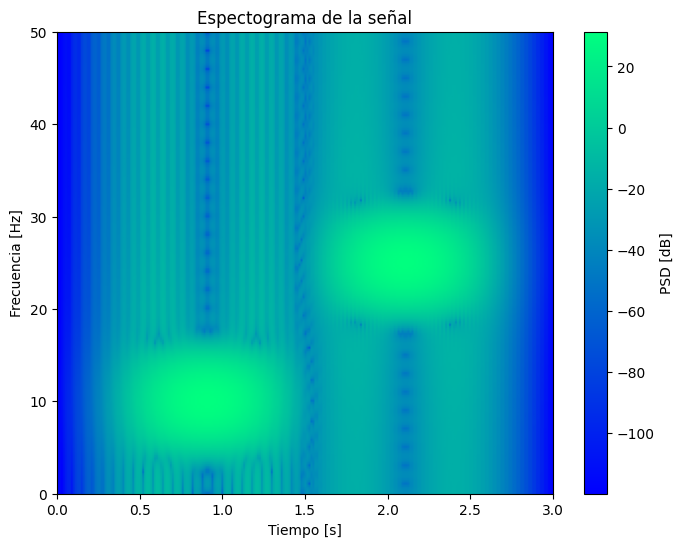

In [156]:
def generar_atomos_gabor(segundos, frecs, frecM, centros, sigma):
    Tm = 1/frecM

    dom = np.arange(0, segundos, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(2 * np.pi * frecs[f] * dom)
        kernel = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(dom - centros[f])**2 / (2 * sigma**2))
        senoidal_final += senoidal * kernel

    return dom, senoidal_final

frecM = 100
dom, signal = generar_atomos_gabor(3, [10, 25], frecM, [1, 2], sigma=.1)
plt.plot(dom, signal)

a, b = espectograma(signal, 'Hamming', Nwin=50, Nlap=1, Nfft=400, start=0)
print(a.shape, b.shape)

graficar_espectograma(b, frecM, Nwin=50, Nlap=1, Nfft=400, freqLap=None)

## Ejercicio 5

(426, 75) (6, 426)


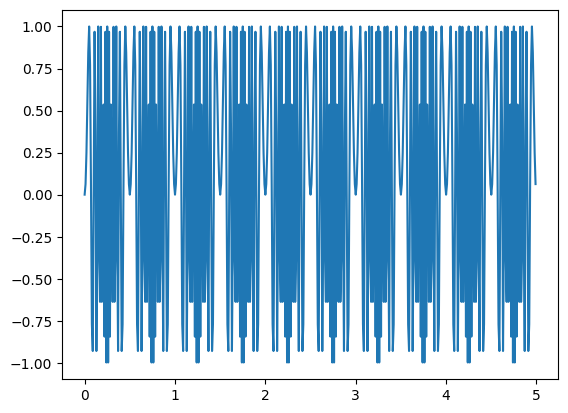

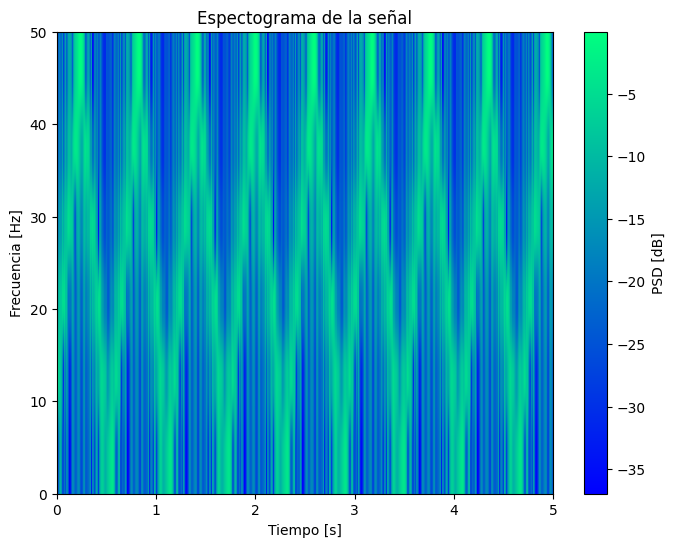

In [157]:
frecM = 100

dom, signal = senoidal_mutante(0, 2 * frecM, 5, frecM, kernel_lineal)
plt.plot(dom, signal)

a, b = espectograma(signal, 'Hamming', Nwin=75, Nlap=1, Nfft=10, start=0)
print(a.shape, b.shape)

graficar_espectograma(b, frecM, Nwin=75, Nlap=1, Nfft=10, freqLap=None)

## Ejercicio 6

(85, 64) (33, 85)


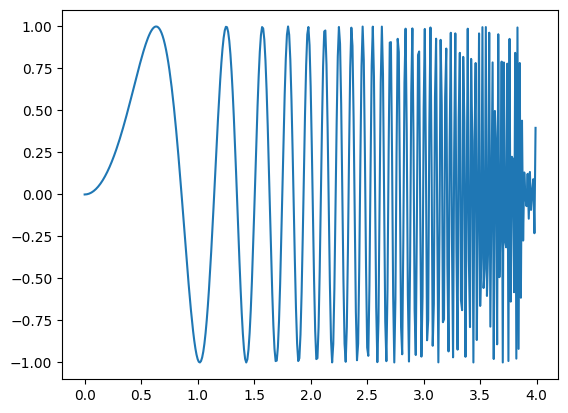

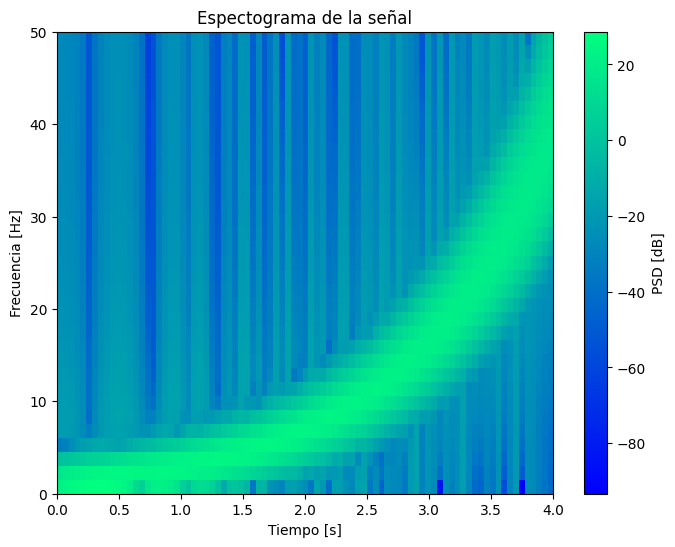

In [158]:
frecM = 100

Nwin = 64
Nfft = 64

dom, signal = senoidal_mutante(1, 50, 4, frecM, kernel_exp)
plt.plot(dom, signal)

a, b = espectograma(signal, 'Hamming', Nwin=Nwin, Nlap=4, Nfft=Nfft, start=0)
print(a.shape, b.shape)

graficar_espectograma(b, frecM, Nwin=Nwin, Nlap=4, Nfft=Nfft, freqLap=None)

Nota del autor: Gran gráfica.